In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import scipy.ndimage
import scipy.optimize

In [2]:
with rasterio.open("../Dutch Bill Creek-pass2.tif") as file:
    gully = file.read(1)[7800:8750, 7750:8500]

In [3]:
begin = (185, 780)
end = (513, 270)

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: -2.1364186063515787
       x: [ 2.124e+02  6.801e+02 ...  5.720e+02  3.130e+02]
     nit: 7
   direc: [[ 1.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
           [ 0.000e+00  1.000e+00 ...  0.000e+00  0.000e+00]
           ...
           [ 0.000e+00  0.000e+00 ...  1.000e+00  0.000e+00]
           [-6.757e+00 -3.863e-01 ...  2.575e-01 -1.118e-05]]
    nfev: 3935

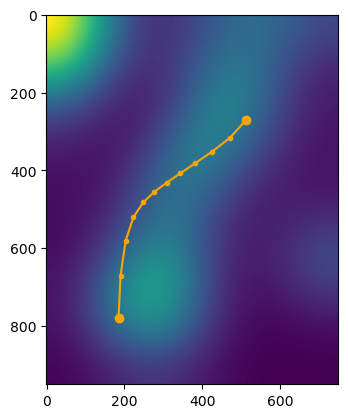

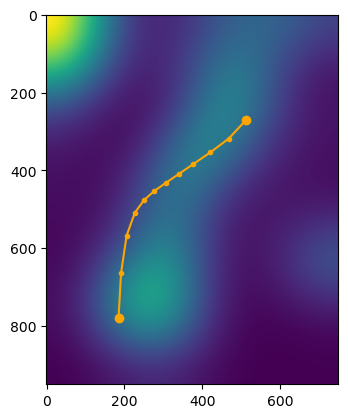

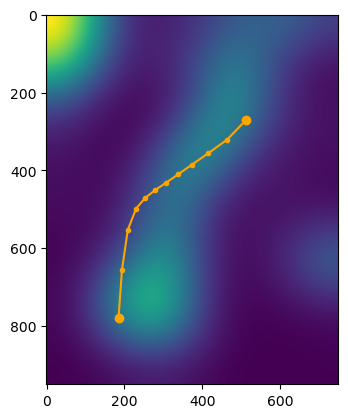

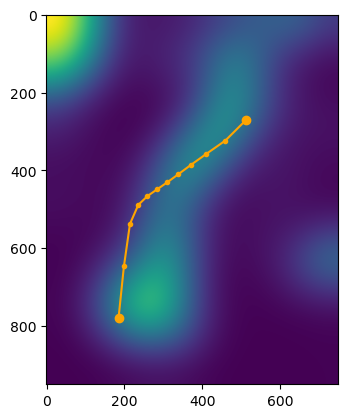

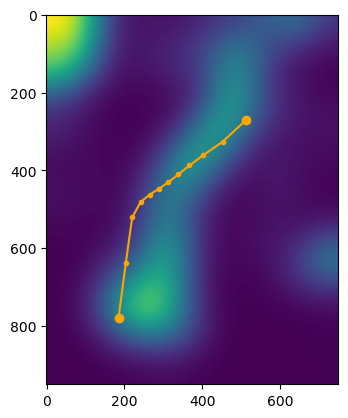

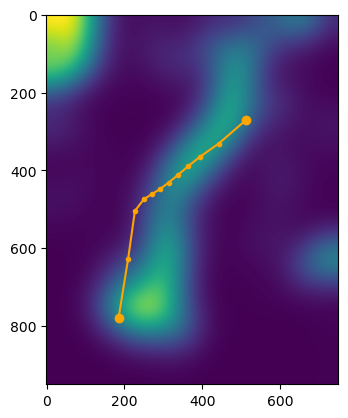

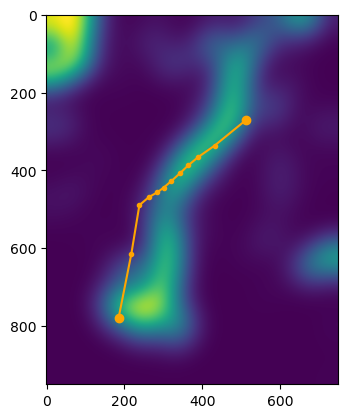

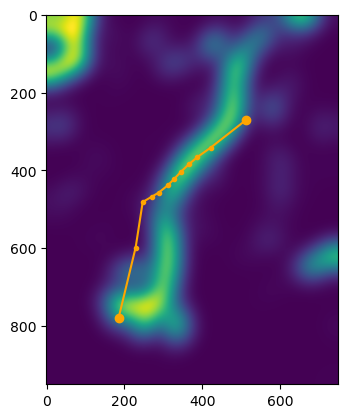

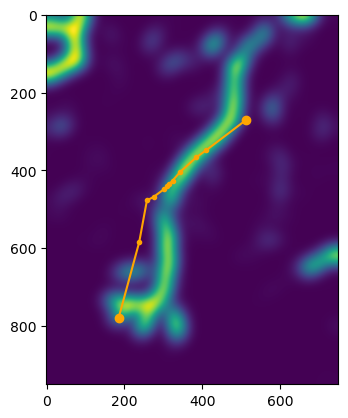

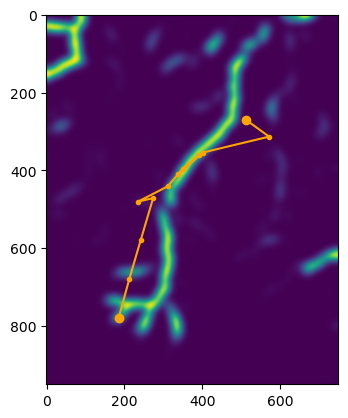

In [26]:
NUM_MIDPOINTS = 10

def arguments_to_line(arguments):
    ij = np.empty((len(arguments) // 2 + 2, 2))
    ij[0] = begin
    ij[-1] = end
    ij[1:-1] = arguments.reshape(-1, 2)
    return ij

def blurry_iteration(guess, sigma, length_constraint):
    bounds = np.tile([0, gully.shape[0], 0, gully.shape[1]], NUM_MIDPOINTS).reshape(-1, 2)

    blurry = scipy.ndimage.gaussian_filter(gully, sigma)
    length_normalization = abs((begin[0] - end[0])**2 + (begin[1] - end[1])**2) * (NUM_MIDPOINTS + 1)

    def objective(arguments):
        ij = arguments_to_line(arguments)
        sum_of_lengths = np.sum(abs(np.sum((ij[1:] - ij[:-1])**2, axis=1))) / length_normalization
        gully_probability = np.sum(scipy.ndimage.map_coordinates(blurry, ij.T, order=1))
        # print(sum_of_lengths, gully_probability)
        return length_constraint * sum_of_lengths - gully_probability

    return scipy.optimize.minimize(objective, guess, bounds=bounds, method="Powell"), guess

guess = np.dstack([
    np.linspace(begin[0], end[0], NUM_MIDPOINTS + 2),
    np.linspace(begin[1], end[1], NUM_MIDPOINTS + 2),
])[0][1:-1].flatten()

for sigma in [100, 90, 80, 70, 60, 50, 40, 30, 20, 10]:
    result, guess = blurry_iteration(guess, sigma, 10)

    fig, ax = plt.subplots()

    ax.imshow(scipy.ndimage.gaussian_filter(gully, sigma))

    midpoints = arguments_to_line(result.x)

    ax.plot(midpoints[:, 0], midpoints[:, 1], marker=".", color="orange")
    ax.scatter([begin[0], end[0]], [begin[1], end[1]], marker="o", color="orange")

result